## **Analyse du secteur pétrolier et gazier au Gabon**

## Contexte

Le pétrole et le gaz occupent une place importante dans l'économie gabonaise. Ce projet vise à analyser l'évolution de la production pétrolière et gazière ainsi que la contribution du secteur pétrolier à l'économie nationale.

## Objectifs

- Étudier l'évolution de la production pétrolière.
- Étudier l'évolution de la production gazière.
- Analyser les rentes pétrolières en pourcentage du PIB.
- Mettre en évidence les tendances observées.

In [1]:
## Importation des bibliothèques. Cette étape permet de charger les bibliothèques Python nécessaires à la manipulation et à l'analyse des données.

import pandas as pd
import numpy as np

## Chargement des données

Les données proviennent de sources publiques :

- Our World in Data pour les productions pétrolière et gazière.
- Banque mondiale pour les rentes pétrolières (% du PIB).

## Connexion à Google Drive

Les fichiers de données utilisés dans ce projet sont stockés dans Google Drive afin d'éviter de devoir les importer manuellement à chaque nouvelle session Colab.

Cette étape permet de connecter le notebook à Google Drive pour accéder directement aux datasets du projet.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Vérification de la présence des fichiers

Avant de charger les données, il est important de vérifier que le notebook accède correctement au dossier contenant les datasets.

Le module `os` (Operating System) permet d'interagir avec le système de fichiers. Il est utilisé ici pour afficher le contenu d'un dossier et vérifier que les fichiers nécessaires au projet sont bien accessibles.


In [3]:
import os
os.listdir('/content/drive/MyDrive/Gabon_oil_&_gas_project')

['data_raw', 'notebooks', 'outputs']

## Importation de la bibliothèque Pandas

Elle permet notamment de charger des fichiers CSV, d'explorer leur contenu et d'effectuer des transformations sur les données.


In [4]:
import pandas as pd

## Chargement du dataset de production pétrolière

Ce dataset provient de la plateforme Our World in Data.

Il contient l'évolution de la production pétrolière de plusieurs pays au fil du temps, exprimée en térawattheures (TWh).

L'objectif est d'étudier l'évolution de la production pétrolière du Gabon.


In [5]:
oil_df = pd.read_csv(
    '/content/drive/MyDrive/Gabon_oil_&_gas_project/data_raw/oil-production-by-country.csv'
)

## Aperçu du dataset

Après le chargement des données, il est recommandé d'afficher les premières lignes du dataset.

Cette étape permet de vérifier que l'importation s'est déroulée correctement et d'identifier les variables disponibles pour l'analyse.


In [6]:
oil_df.head()

,entity,code,year,oil_production__twh
0,Afghanistan,AFG,1980,0.0
1,Afghanistan,AFG,1981,0.0
2,Afghanistan,AFG,1982,0.0
3,Afghanistan,AFG,1983,0.0
4,Afghanistan,AFG,1984,0.0


On peut observer que le dataset contient quatre variables qui correspondent respectivement au nom du pays, au code ISO du pays, l'année d'observation et la production pétrolière exprimée en térawattheures (TWh).
Les premières lignes affichées correspondent à l'Afghanistan, ce qui confirme que le que le dataset contient les données de plusieurs pays et devra être filtré pour ne conserver que le Gabon.

## Dimensions du dataset

L'analyse des dimensions permet de connaître le nombre d'observations et le nombre de variables présentes dans le jeu de données.

Cette information donne une première idée de la taille du dataset.


In [7]:
oil_df.shape

(17992, 4)

Le jeu de données contient 17 992 observations et 4 variables. Cette taille est suffisante pour réaliser une analyse temporelle de la production pétrolière tout en restant facilement exploitable avec Pandas.

## Structure du dataset

Cette étape permet d'identifier le type de données de chaque variable ainsi que le nombre de valeurs non nulles.

Elle est essentielle pour détecter d'éventuels problèmes de qualité des données avant l'analyse.


In [8]:
oil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17992 entries, 0 to 17991
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   entity               17992 non-null  object 
 1   code                 15574 non-null  object 
 2   year                 17992 non-null  int64  
 3   oil_production__twh  17992 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 562.4+ KB


L'exploration de la structure du dataset montre que la majorité des variables ne contiennent aucune valeur manquante.

Seule la variable **code** présente des valeurs absentes. Ces derniers peuvent correspondre à des regroupements géographiques ou économiques ou statistiques.

 Une vérification complémentaire sera réalisée lors du nettoyage des données.

## Recherche des valeurs manquantes

La détection des valeurs manquantes constitue une étape importante de l'exploration des données.

Elle permet d'identifier d'éventuels problèmes de qualité susceptibles d'influencer les analyses futures.


In [9]:
oil_df.isnull().sum()

,0
entity,0
code,2418
year,0
oil_production__twh,0


# Validation de la qualité des données

L'analyse des valeurs manquantes confirme que la variable d'intérêt du projet. oil_production_twh,est complète sur l'ensemble du dataset.

Les seules valeurs absentes concernent la variable **code** avec 2 418 observations manquantes. Ceci n'affecte pas directement l'étude de la production pétrolière puisqu'elle ne touche ni les années d'observation ni les volumes de production.

Les données apparaissent donc suffisament complètes pour poursuivre l'analyse exploratoire et le filtrage des observations relatives au Gabon.

## Extraction des données relatives au Gabon

Le dataset contient des observations pour de nombreux pays et territoires.

Dans le cadre de ce projet, l'analyse porte exclusivement sur le Gabon. Un filtrage va donc être réalisé afin de conserver uniquement les données correspondant à ce pays.


In [10]:
gabon_oil_df = oil_df[oil_df['entity'] == 'Gabon'] #dans ce data frame, conserve uniquement les lignes où cette colonne contient le gabon

## Vérification du sous-ensemble gabonais

Après le filtrage, on affiche un aperçu des premières observations afin de vérifier que seules les données relatives au Gabon ont été conservées.


In [11]:
gabon_oil_df.head()

,entity,code,year,oil_production__twh
6279,Gabon,GAB,1900,0.0
6280,Gabon,GAB,1901,0.0
6281,Gabon,GAB,1902,0.0
6282,Gabon,GAB,1903,0.0
6283,Gabon,GAB,1904,0.0


L'aperçu du sous-ensemble obtenu confirme que le filtrage a été effectué correctement : toutes les observations affichées concernent le Gabon et sont associées au code pays GAB.

Les premières années disponibles remontent à 1900 et présentent une production pétrolière nulle. Cette observation suggère que l'activité pétrolière n'était pas encore développée ou enregistrée à cette période.

Le sous-ensemble obtenu est désormais prêt pour une analyse spécifique du secteur pétrolier gabonais.

## Analyse des dimensions du sous-ensemble gabonais

Après l'extraction des données relatives au Gabon, il est nécessaire d'examiner les dimensions du nouveau DataFrame.

Cette étape permet de vérifier le nombre d'observations conservées après le filtrage ainsi que le nombre de variables disponibles pour la suite de l'analyse.

La comparaison avec les dimensions du dataset initial permettra également d'évaluer l'impact du filtrage effectué.


In [12]:
gabon_oil_df.shape

(125, 4)

Le sous-ensemble gabonais contient 125 observations réparties sur 4 variables.

Comparé au dataset initial de 17 992 enregistrements, ce résultat confirme que le filtrage a correctement isolé les données relatives au Gabon.

Le nombre d'enregistrements suggère une couverture historique importante qui sera analysée plus en détail.

## Analyse de la couverture temporelle des données

L'examen des dimensions du sous-ensemble gabonais a montré que celui-ci contient 125 observations.

Avant d'étudier l'évolution de la production pétrolière, il est nécessaire de comprendre à quoi correspondent ces observations et sur quelle période elles sont réparties.

L'identification des années minimale et maximale permettra de déterminer la couverture temporelle du dataset et de mieux contextualiser les analyses qui suivront.


In [13]:
gabon_oil_df['year'].min()

1900

In [14]:
gabon_oil_df['year'].max()

2024

Les données disponibles pour le Gabon couvrent une période comprise entre 1900 et 2024, soit 125 années d'observation.

Cette couverture temporelle particulièrement étendue constitue un atout pour l'analyse puisqu'elle permet d'étudier l'évolution du secteur pétrolier sur le long terme.

Cependant, l'aperçu des premières observations a montré que les premières années présentent une production pétrolière nulle. La présence de données depuis 1900 ne signifie donc pas nécessairement que l'exploitation pétrolière était déjà active à cette époque.

Il apparaît dès lors pertinent d'examiner plus précisément à partir de quelle période la production pétrolière gabonaise devient effectivement significative.


## Identification du début de la production pétrolière

L'analyse de la couverture temporelle a montré que les données débutent en 1900. Toutefois, les premières observations présentent une production pétrolière nulle.

Afin de mieux comprendre le développement du secteur pétrolier gabonais, il est nécessaire d'identifier la première année pour laquelle une production supérieure à zéro est enregistrée.


In [15]:
gabon_oil_df[gabon_oil_df['oil_production__twh'] > 0].head()

,entity,code,year,oil_production__twh
6336,Gabon,GAB,1957,2.01199
6337,Gabon,GAB,1958,5.87315
6338,Gabon,GAB,1959,8.75739
6339,Gabon,GAB,1960,9.30400
6340,Gabon,GAB,1961,9.00162


L'analyse montre que la première production pétrolière enregistrée dans le dataset apparaît en 1957.

Cette observation permet de mieux comprendre les résultats précédents : bien que les données couvrent la période 1900-2024, l'activité pétrolière gabonaise n'apparaît dans les données qu'à partir de la fin des années 1950.

Les années antérieures à 1957 présentent une production nulle dans le dataset. Elles permettent de situer historiquement le début de l'activité pétrolière, mais leur inclusion dans certaines visualisations pourrait réduire la lisibilité de l'évolution réelle de la production après le démarrage du secteur.


## Vérification de l'ordre chronologique

Après avoir identifié la période de production pétrolière effective, il est nécessaire de vérifier que les observations sont bien organisées dans l'ordre des années.

Cette vérification est importante avant de réaliser une analyse d'évolution temporelle, car une série mal ordonnée pourrait fausser la lecture des tendances.


In [16]:
gabon_oil_df['year'].is_monotonic_increasing

True

La vérification confirme que les observations sont déjà classées dans l'ordre chronologique, de la plus ancienne à la plus récente.

Aucune opération de tri supplémentaire n'est donc nécessaire avant la réalisation des analyses temporelles.

Cette organisation garantit que les futures visualisations représenteront correctement l'évolution de la production pétrolière gabonaise au fil des années et permet désormais d'examiner les principales tendances observées depuis le début de l'exploitation pétrolière.


## Focalisation sur la période d'exploitation pétrolière

L'identification de la première production pétrolière enregistrée en 1957 a montré qu'une partie importante des observations correspond à une période durant laquelle aucune activité pétrolière n'est recensée.

Afin de concentrer l'analyse sur l'évolution réelle du secteur pétrolier gabonais, seules les années correspondant à une activité pétrolière effective sont retenues pour la suite de l'analyse.

Ce choix permet d'éviter que les périodes sans exploitation ne biaisent l'interprétation des tendances observées dans les visualisations futures.


In [17]:
gabon_oil_active_df = gabon_oil_df[
    gabon_oil_df['oil_production__twh'] > 0
]

In [18]:
gabon_oil_active_df.shape

(68, 4)

Après suppression des années ne présentant aucune production pétrolière, le sous-ensemble étudié contient désormais 68 observations réparties sur 4 variables.

Cette réduction du nombre d'enregistrements est cohérente avec l'identification de 1957 comme première année de production enregistrée dans le dataset.

Le nouveau périmètre d'analyse est désormais centré sur la période d'exploitation pétrolière effective du Gabon, ce qui permettra d'étudier plus précisément les évolutions du secteur sans être influencé par les années antérieures à son développement.


## Analyse de l'évolution de la production pétrolière

Les étapes précédentes ont permis de constituer un sous-ensemble de données centré exclusivement sur la période d'exploitation pétrolière du Gabon.

Il est désormais possible d'examiner l'évolution de la production au fil du temps afin d'identifier les principales phases de croissance, de stabilité ou de recul du secteur.

Une représentation graphique sera utilisée pour mettre en évidence les tendances générales observées sur l'ensemble de la période étudiée.


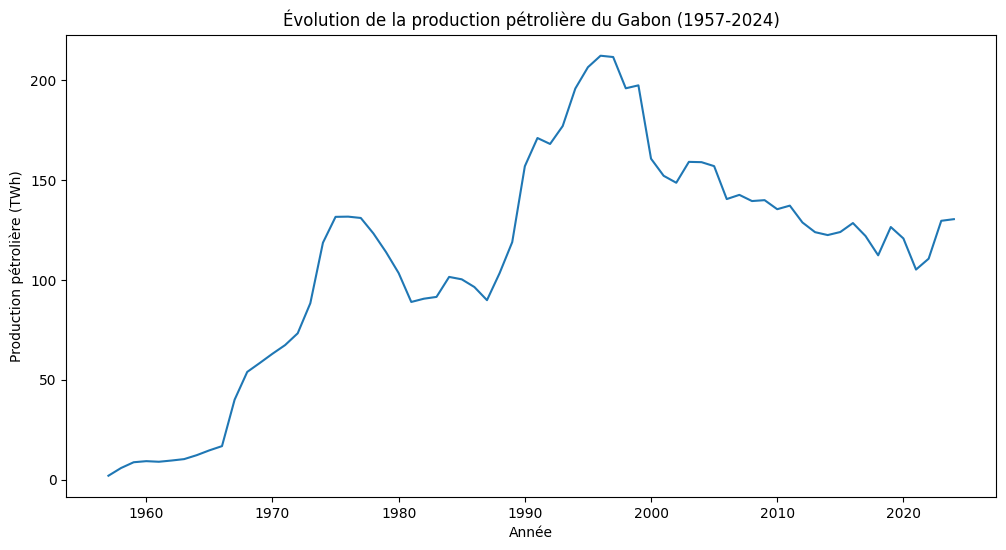

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    gabon_oil_active_df['year'],
    gabon_oil_active_df['oil_production__twh']
)

plt.title("Évolution de la production pétrolière du Gabon (1957-2024)")
plt.xlabel("Année")
plt.ylabel("Production pétrolière (TWh)")

plt.show()

## Vérification des dernières observations disponibles

L'exploration précédente a montré que le dataset couvre théoriquement la période 1900-2024.

Toutefois, la représentation graphique semble s'arrêter autour de l'année 2020. Avant d'interpréter les tendances observées, il est nécessaire de vérifier les dernières observations présentes dans le sous-ensemble afin de confirmer la couverture effective des données de production pétrolière.


In [20]:
gabon_oil_active_df.tail()

,entity,code,year,oil_production__twh
6399,Gabon,GAB,2020,120.779150
6400,Gabon,GAB,2021,105.205080
6401,Gabon,GAB,2022,110.651505
6402,Gabon,GAB,2023,129.619050
6403,Gabon,GAB,2024,130.434190


L'examen des dernières observations confirme que les données de production pétrolière sont bien disponibles jusqu'en 2024.
L'impression d'un arrêt de la série autour de 2020 observée sur le graphique est donc liée à l'affichage des graduations de l'axe temporel et non à une absence de données.

Le dataset couvre ainsi l'ensemble de la période d'exploitation pétrolière étudiée, permettant une analyse des tendances les plus récentes du secteur.


# Analyse du pic de production pétrolière

L'observation du graphique suggère l'existence d'un pic de production au cours de la période étudiée.

Afin de confirmer cette impression visuelle et d'identifier précisément l'année concernée, il est pertinent de rechercher l'observation présentant le niveau de production pétrolière le plus élevé du dataset.

In [21]:
gabon_oil_active_df.loc[
    gabon_oil_active_df['oil_production__twh'].idxmax()
]

,6375
entity,Gabon
code,GAB
year,1996
oil_production__twh,212.2475


L'analyse confirme que le niveau de production pétrolière le plus élevé observé dans le dataset est atteint en 1996 avec une production de 212,25 TWh.

L'identification précise de cette année de référence permet désormais d'interpréter plus finement les évolutions observées avant et après ce maximum de production.

### Analyse de l'évolution de la production pétrolière gabonaise ( graphique )

La visualisation met en évidence plusieurs phases distinctes dans l'évolution de la production pétrolière du Gabon.

Une première phase de croissance est observée entre le début de l'exploitation pétrolière en 1957 et le milieu des années 1990. Cette période est marquée par une augmentation progressive de la production, traduisant le développement du secteur pétrolier national.

La production atteint son niveau maximal en 1996 avec 212,25 TWh, constituant le point culminant de la série étudiée.

À partir de cette date, une tendance générale à la baisse est observée. Bien que progressive, cette diminution se prolonge sur plusieurs décennies et conduit à des niveaux de production inférieurs à ceux enregistrés lors du pic de 1996.

Les données les plus récentes montrent toutefois le maintien d'une activité pétrolière significative. En 2024, la production atteint encore 130,43 TWh, bien que ce niveau demeure inférieur au maximum observé en 1996.

## Analyse de la production de gaz naturel

L'étude de la production pétrolière a permis de mettre en évidence plusieurs phases de développement du secteur énergétique gabonais.

Toutefois, le pétrole ne constitue pas la seule ressource énergétique exploitée dans le pays. Afin d'obtenir une vision plus complète du secteur, il apparaît pertinent d'examiner également l'évolution de la production de gaz naturel.

L'objectif est de déterminer si cette ressource suit des tendances similaires à celles observées pour le pétrole ou si son évolution présente des caractéristiques différentes.


In [22]:
gas_df = pd.read_csv(
    '/content/drive/MyDrive/Gabon_oil_&_gas_project/data_raw/fossil-fuels.csv'
)

Avant de réaliser des analyses plus approfondies, il est toujours nécessaire d'examiner les premières observations du jeu de données afin de vérifier le bon chargement du fichier et d'identifier les principales variables disponibles pour l'étude de la production du gaz naturel.

In [23]:
gas_df.head()

,entity,code,year,natural_gas_production
0,Afghanistan,AFG,1980,1.699011e+09
1,Afghanistan,AFG,1981,2.237031e+09
2,Afghanistan,AFG,1982,2.293664e+09
3,Afghanistan,AFG,1983,2.406932e+09
4,Afghanistan,AFG,1984,2.406932e+09


L'aperçu du dataset confirme la présence des informations nécessaires à l'analyse de la production de gaz naturel : pays, code pays, année d'observation et volume de production.

La structure du fichier est similaire à celle utilisée pour l'étude de la production pétrolière, ce qui facilitera les comparaisons entre les deux ressources énergétiques dans les étapes suivantes.

## Extraction des données relatives au Gabon

Le jeu de données regroupe les informations de nombreux pays.

Afin de conserver une cohérence avec l'analyse pétrolière précédemment réalisée, seules les observations relatives au Gabon seront extraites pour les étapes suivantes.


In [24]:
gabon_gas_df = gas_df[
    gas_df['entity'] == 'Gabon'
]

In [25]:
gabon_gas_df.head()

,entity,code,year,natural_gas_production
3602,Gabon,GAB,1980,70792120.0
3603,Gabon,GAB,1981,59465380.0
3604,Gabon,GAB,1982,56633692.0
3605,Gabon,GAB,1983,150079280.0
3606,Gabon,GAB,1984,150079280.0


In [26]:
gabon_gas_df.shape

(45, 4)

Le filtrage confirme que les données relatives au Gabon ont été correctement isolées. Les premières observations disponibles débutent en 1980 et présentent déjà une production de gaz naturel non nulle.

Le sous-ensemble obtenu contient 45 observations réparties sur 4 variables, soit un volume de données plus restreint que celui observé pour le pétrole. Cette différence suggère une période de couverture plus courte, qui mérite d'être examinée avant de poursuivre l'analyse.

## Analyse de la couverture temporelle

Le sous-ensemble gazier contient moins d'observations que celui consacré au pétrole.

Il est donc nécessaire de déterminer précisément la période couverte par les données afin de mieux comprendre l'étendue temporelle de l'analyse et de faciliter les comparaisons entre les deux ressources énergétiques.


In [27]:
gabon_gas_df['year'].min()

1980

In [28]:
gabon_gas_df['year'].max()

2024


Les données relatives à la production de gaz naturel couvrent la période 1980-2024, soit 45 années d'observation.

Contrairement au dataset pétrolier, aucune période prolongée sans production n'apparaît dans les premières observations disponibles. Les données semblent donc se concentrer directement sur la période d'exploitation effective du gaz naturel.

Cette couverture temporelle permet désormais d'étudier l'évolution de la production gazière et de la comparer aux tendances précédemment observées pour le pétrole.


## Vérification de l'ordre chronologique

Avant d'analyser l'évolution de la production de gaz naturel, il convient de vérifier que les observations sont correctement ordonnées dans le temps.

Cette vérification garantit la fiabilité des futures visualisations et facilite l'interprétation des tendances observées.


In [29]:
gabon_gas_df['year'].is_monotonic_increasing

True

Les observations sont correctement ordonnées de manière chronologique. Aucune opération de tri supplémentaire n'est donc nécessaire avant la réalisation des analyses temporelles.

Les données sont désormais prêtes à être visualisées afin d'étudier l'évolution de la production de gaz naturel sur la période 1980-2024.


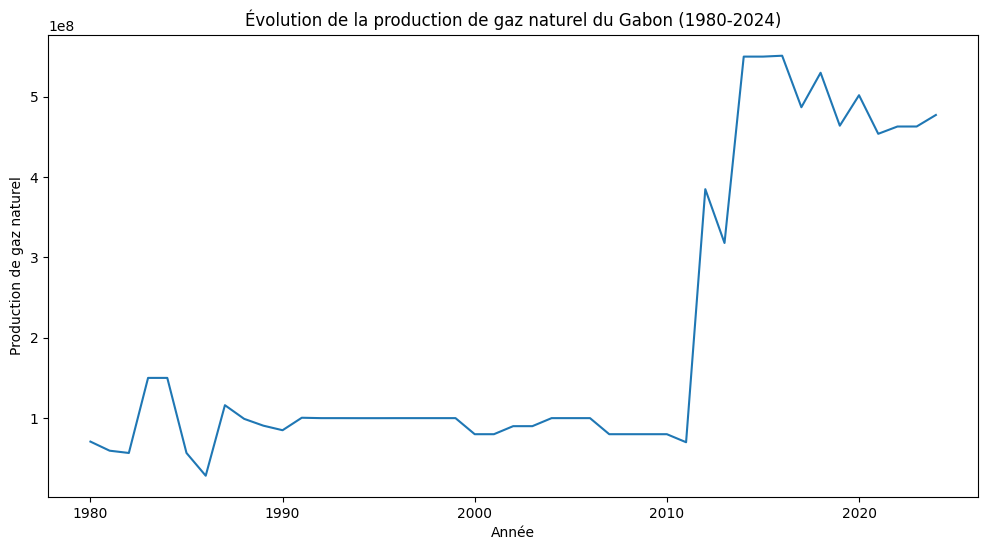

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    gabon_gas_df['year'],
    gabon_gas_df['natural_gas_production']
)

plt.title("Évolution de la production de gaz naturel du Gabon (1980-2024)")
plt.xlabel("Année")
plt.ylabel("Production de gaz naturel")

plt.show()

Contrairement au dataset pétrolier, l'intitulé de la variable de production gazière ne précise pas directement l'unité utilisée.

Afin d'éviter une mauvaise interprétation des résultats, il est nécessaire de vérifier le nom exact de la variable et son contexte avant de commenter les niveaux de production observés.

In [31]:
gabon_gas_df.columns

Index(['entity', 'code', 'year', 'natural_gas_production'], dtype='object')

In [32]:
gabon_gas_df['natural_gas_production'].max()

551100500.0

In [33]:
gabon_gas_df.tail()

,entity,code,year,natural_gas_production
3642,Gabon,GAB,2020,501943940.0
3643,Gabon,GAB,2021,453900400.0
3644,Gabon,GAB,2022,462978430.0
3645,Gabon,GAB,2023,463000450.0
3646,Gabon,GAB,2024,477353440.0


La vérification des informations disponibles confirme que le dataset contient une variable dédiée à la production de gaz naturel.
Le niveau maximal enregistré atteint 551 100 500 unités de production, confirmant la présence d'une phase de forte augmentation de la production au cours de la période étudiée.

L'examen des dernières observations montre également que les données sont disponibles jusqu'en 2024. L'absence apparente des dernières années sur le graphique est donc uniquement liée à l'affichage automatique des graduations de l'axe temporel.

Ces vérifications permettent désormais d'interpréter l'évolution de la production gazière sur l'ensemble de la période 1980-2024.


## Identification du pic de production gazière

L'observation du graphique met en évidence une hausse importante de la production de gaz naturel après 2010.

Afin de confirmer cette observation et d'identifier précisément l'année où la production atteint son niveau maximal, la valeur maximale du dataset sera recherchée.


In [34]:
gabon_gas_df.loc[
    gabon_gas_df['natural_gas_production'].idxmax()
]

,3638
entity,Gabon
code,GAB
year,2016
natural_gas_production,551100500.0


La recherche de la valeur maximale confirme que le niveau le plus élevé de production de gaz naturel est atteint en 2016, avec 551 100 500 unités de production.

Cette vérification confirme l'observation faite à partir du graphique : la production gazière connaît une accélération importante après 2010, contrairement à la production pétrolière qui atteint son pic plusieurs décennies plus tôt.

Le gaz naturel semble donc suivre une dynamique plus récente, avec une phase de croissance concentrée principalement au cours des années 2010.

### Conclusion de l'analyse de la production énergétique

L'analyse comparée des productions pétrolière et gazière met en évidence deux trajectoires différentes.

La production pétrolière gabonaise a connu son apogée en 1996 avant d'amorcer une diminution progressive.

À l'inverse, la production de gaz naturel présente une dynamique plus récente, avec une accélération notable après 2010 et un maximum atteint en 2016.

Ces évolutions montrent que les différentes ressources énergétiques ne suivent pas nécessairement les mêmes cycles de développement. L'analyse de leur poids économique permettra désormais d'évaluer si ces transformations de production se traduisent par une évolution similaire de l'importance du secteur dans l'économie gabonaise.


## Chargement de l'indicateur économique

Après l'analyse des volumes de production pétrolière et gazière, l'étude se poursuit avec une dimension économique.

L'objectif est maintenant d'observer l'évolution des rentes pétrolières, exprimées en pourcentage du PIB, afin d'évaluer la place occupée par les revenus issus de l'exploitation pétrolière dans l'économie gabonaise.

Le dataset provenant de la Banque mondiale est chargé afin d'extraire les informations nécessaires à cette analyse.


In [35]:
import os

os.listdir('/content/drive/MyDrive/Gabon_oil_&_gas_project/data_raw')

['oil-production-by-country.csv',
 'fossil-fuels.csv',
 'API_NY.GDP.PETR.RT.ZS_DS2_en_csv_v2_432941.csv']

In [36]:
with open(
    '/content/drive/MyDrive/Gabon_oil_&_gas_project/data_raw/API_NY.GDP.PETR.RT.ZS_DS2_en_csv_v2_432941.csv',
    'r',
    encoding='utf-8'
) as f:
    for i in range(10):
        print(f.readline())

﻿"Data Source","World Development Indicators",



"Last Updated Date","2026-04-08",



"Country Name","Country Code","Indicator Name","Indicator Code","1960","1961","1962","1963","1964","1965","1966","1967","1968","1969","1970","1971","1972","1973","1974","1975","1976","1977","1978","1979","1980","1981","1982","1983","1984","1985","1986","1987","1988","1989","1990","1991","1992","1993","1994","1995","1996","1997","1998","1999","2000","2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025",

"Aruba","ABW","Oil rents (% of GDP)","NY.GDP.PETR.RT.ZS","","","","","","","","","","","","","","","","","","","","","","","","","","","0","0","0","0","0","0","0","0","0","0","0","0","0","0","0.000959488886147264","0.000698232167894007","0.000720702919318894","0.000760651086559827","0.000906166596082593","0.00131405293432615","0.00152577280324417","0.00153973985727839","0.0019564000

L'inspection du fichier montre la présence de plusieurs lignes de métadonnées décrivant la source et la date de mise à jour des informations.

Ces éléments ne font pas partie du jeu de données à analyser. Le chargement est donc effectué en ignorant ces lignes afin de conserver uniquement le tableau contenant les observations par pays et par année.

In [37]:
oil_rents_df = pd.read_csv(
    '/content/drive/MyDrive/Gabon_oil_&_gas_project/data_raw/API_NY.GDP.PETR.RT.ZS_DS2_en_csv_v2_432941.csv',
    skiprows=4
)

In [38]:
oil_rents_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.325342,3.020676,2.468533,1.326026,2.32444,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.013427,0.018854,0.012777,0.005178,0.01787,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.610533,6.559928,5.862979,2.984596,5.42693,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.711006,30.730403,27.504829,18.571960,28.27444,NaN,NaN,NaN,NaN,NaN


L'aperçu du dataset confirme que les données sont organisées différemment des jeux de données précédemment utilisés pour les productions pétrolière et gazière.

Les observations sont regroupées par pays, tandis que chaque année est représentée par une colonne distincte. Le fichier contient également des informations descriptives telles que le nom du pays, son code ainsi que l'intitulé de l'indicateur étudié.

Afin de concentrer l'analyse sur le Gabon et de faciliter les traitements ultérieurs, il est nécessaire d'extraire la ligne correspondant au pays puis de réorganiser les données sous un format plus adapté à l'analyse temporelle.


## Extraction des données relatives au Gabon

Le dataset contient les informations de nombreux pays et regroupements régionaux.

Afin de répondre à la problématique de cette étude, seules les données correspondant au Gabon sont conservées pour les analyses suivantes.


In [39]:
gabon_rents_df = oil_rents_df[
    oil_rents_df['Country Code'] == 'GAB'
]

gabon_rents_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
80,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,14.393258,18.327408,16.684243,9.979824,15.556509,NaN,NaN,NaN,NaN,NaN


Le filtrage a permis d'isoler les données relatives au Gabon. Le sous-ensemble obtenu ne contient qu'une seule observation, regroupant l'ensemble des valeurs annuelles de l'indicateur étudié.

Les années étant actuellement réparties dans différentes colonnes, une transformation du format des données est nécessaire afin de faciliter l'analyse temporelle et la réalisation des visualisations.

## Transformation du format des données

Les valeurs des rentes pétrolières sont actuellement réparties dans des colonnes correspondant aux différentes années.

Afin de faciliter les traitements statistiques et les représentations graphiques, les données sont converties vers un format où chaque ligne représente une année et la valeur associée de l'indicateur.


In [40]:
gabon_rents_long = gabon_rents_df.melt(
    id_vars=[
        'Country Name',
        'Country Code',
        'Indicator Name',
        'Indicator Code'
    ],
    var_name='year',
    value_name='oil_rents_pct_gdp'
)

gabon_rents_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,oil_rents_pct_gdp
0,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1960,NaN
1,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1961,NaN
2,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1962,NaN
3,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1963,NaN
4,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1964,NaN


La transformation a permis de convertir le jeu de données vers un format adapté à l'analyse temporelle. Chaque ligne correspond désormais à une année et à la valeur associée des rentes pétrolières exprimées en pourcentage du PIB.

Les premières années contiennent des valeurs manquantes, ce qui indique une absence de données disponibles pour ces périodes et non une erreur liée à la transformation réalisée.

Avant de poursuivre l'analyse, il est nécessaire d'identifier les années effectivement renseignées afin de travailler uniquement sur les observations exploitables.

## Identification des observations exploitables

Certaines années ne disposent pas de valeur renseignée pour l'indicateur étudié.

Afin de garantir la qualité de l'analyse, seules les observations contenant une valeur de rentes pétrolières sont conservées.


In [41]:
gabon_rents_clean = gabon_rents_long.dropna(
    subset=['oil_rents_pct_gdp']
)

gabon_rents_clean.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,oil_rents_pct_gdp
10,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1970,2.829820
11,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1971,1.029029
12,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1972,3.409310
13,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1973,4.298717
14,Gabon,GAB,Oil rents (% of GDP),NY.GDP.PETR.RT.ZS,1974,39.000133


In [42]:
gabon_rents_clean.shape

(52, 6)

La suppression des valeurs manquantes a permis de conserver uniquement les années pour lesquelles l'indicateur de rentes pétrolières est renseigné.

Les premières données exploitables apparaissent à partir de 1970. Le jeu de données nettoyé contient désormais 52 observations et 6 variables, ce qui constitue une base suffisante pour analyser l'évolution du poids économique des revenus pétroliers au Gabon sur le long terme.


#Vérification de la période couverte

Après avoir identifié les observations exploitables, il convient de vérifier précisément la période couverte par les données afin de connaître l'étendue temporelle de l'analyse économique.


In [43]:
gabon_rents_clean['year'].min()

'1970'

In [44]:
gabon_rents_clean['year'].max()

'2021'

Les données exploitables couvrent la période allant de 1970 à 2021.

Cette période offre plus de cinquante années d'observation, ce qui permet d'étudier l'évolution du poids économique des revenus pétroliers dans l'économie gabonaise sur le long terme et d'identifier les éventuelles phases de croissance ou de recul de leur importance relative.

## Analyse de l'évolution des rentes pétrolières (% du PIB)

Après avoir identifié la période couverte par les données, une représentation graphique est réalisée afin d'observer l'évolution des rentes pétrolières exprimées en pourcentage du PIB.

Cette visualisation permettra de mettre en évidence les périodes où les revenus issus de l'exploitation pétrolière occupaient une place plus ou moins importante dans l'économie gabonaise.

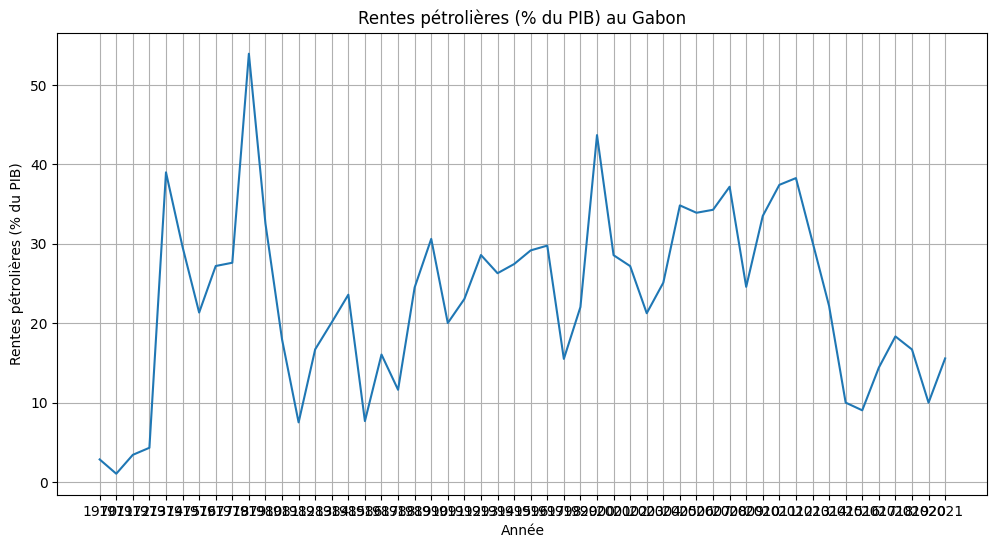

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(
    gabon_rents_clean['year'],
    gabon_rents_clean['oil_rents_pct_gdp']
)

plt.title("Rentes pétrolières (% du PIB) au Gabon")
plt.xlabel("Année")
plt.ylabel("Rentes pétrolières (% du PIB)")
plt.grid(True)

plt.show()

In [46]:
gabon_rents_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 10 to 61
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       52 non-null     object 
 1   Country Code       52 non-null     object 
 2   Indicator Name     52 non-null     object 
 3   Indicator Code     52 non-null     object 
 4   year               52 non-null     object 
 5   oil_rents_pct_gdp  52 non-null     float64
dtypes: float64(1), object(5)
memory usage: 4.9+ KB


**Convertion de la variable temporelle**

Après la transformation du dataset, la variable représentant les années est stockée sous forme de texte.

Afin de garantir une représentation chronologique correcte et de faciliter les traitements ultérieurs, cette variable sera convertie vers un format numérique.

In [47]:
gabon_rents_clean = gabon_rents_long.dropna(
    subset=['oil_rents_pct_gdp']
).copy()

In [48]:
gabon_rents_clean['year'] = gabon_rents_clean['year'].astype(int)
gabon_rents_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52 entries, 10 to 61
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country Name       52 non-null     object 
 1   Country Code       52 non-null     object 
 2   Indicator Name     52 non-null     object 
 3   Indicator Code     52 non-null     object 
 4   year               52 non-null     int64  
 5   oil_rents_pct_gdp  52 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.8+ KB


On peut constater que la conversion a été réalisée avec succès. La variable year est désormais reconnue comme une donnée numérique (int64).

Cette modification garantit une représentation chronologique correcte des observations et améliore la qualité des analyses temporelles qui seront réalisées par la suite.

## Amélioration de la visualisation

Une première représentation graphique a été réalisée afin d'observer l'évolution des rentes pétrolières au Gabon. Toutefois, la lecture de l'axe temporel s'est révélée difficile en raison du format de la variable `year`, initialement stockée sous forme de texte.

Après conversion de cette variable en format numérique, une nouvelle visualisation est produite afin d'obtenir une représentation chronologique plus lisible et de faciliter l'interprétation des tendances observées.


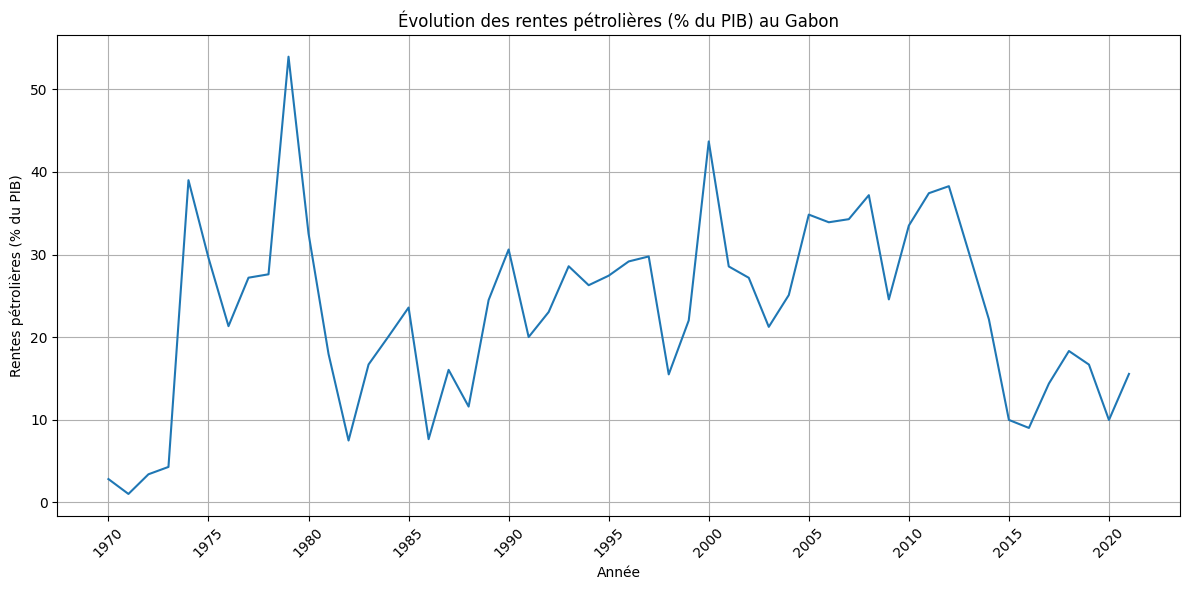

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    gabon_rents_clean['year'],
    gabon_rents_clean['oil_rents_pct_gdp']
)

plt.xticks(
    range(1970, 2022, 5),
    rotation=45
)

plt.title("Évolution des rentes pétrolières (% du PIB) au Gabon")
plt.xlabel("Année")
plt.ylabel("Rentes pétrolières (% du PIB)")
plt.grid(True)

plt.tight_layout()

plt.show()

L'évolution des rentes pétrolières montre une montée rapide de l'importance du secteur pétrolier dans l'économie gabonaise au cours des années 1970.

Entre le début et la fin des années 1970, la contribution du pétrole au PIB augmente fortement, jusqu'à atteindre un niveau supérieur à 50 %. Cette période traduit une forte dépendance de l'économie gabonaise aux revenus issus de l'exploitation pétrolière.

Après cette phase de forte contribution, le poids du pétrole dans le PIB diminue progressivement, malgré une remontée observée autour des années 2000.

À partir de 2015, la part des rentes pétrolières dans le PIB baisse fortement pour atteindre des niveaux plus faibles. Cette évolution traduit une diminution du poids relatif du pétrole dans l'économie, et non une disparition de l'activité pétrolière, qui reste un secteur stratégique pour le Gabon.

## Du niveau de production à l'impact économique

L'analyse des niveaux de production pétrolière et gazière a permis d'observer l'évolution de l'activité extractive au Gabon.

Toutefois, les volumes produits ne permettent pas à eux seuls d'évaluer l'importance économique du secteur. Cette analyse est donc complétée par l'étude des revenus pétroliers en proportion du PIB afin de mieux comprendre la contribution du secteur à l'économie gabonaise.


## Synthèse des données analysées

Afin de regrouper les différents indicateurs étudiés, un tableau de synthèse est créé.

Il permet de rappeler les différentes dimensions analysées :

* la production pétrolière ;
* la production gazière ;
* la contribution économique du pétrole dans le PIB.

Pour les données de production, la période retenue correspond au début de l'activité observée, afin d'éviter de considérer les années antérieures sans production effective.

Cette synthèse facilite la comparaison des périodes couvertes avant de formuler les conclusions finales.


In [50]:
gabon_summary = pd.DataFrame({
    'Indicateur': [
        'Production pétrolière',
        'Production gazière',
        'Rentes pétrolières (% du PIB)'
    ],
    'Début activité observée': [
        gabon_oil_df[gabon_oil_df['oil_production__twh'] > 0]['year'].min(),
        gabon_gas_df[gabon_gas_df['natural_gas_production'] > 0]['year'].min(),
        gabon_rents_clean[gabon_rents_clean['oil_rents_pct_gdp'] > 0]['year'].min()
    ],
    'Dernière année disponible': [
        gabon_oil_df['year'].max(),
        gabon_gas_df['year'].max(),
        gabon_rents_clean['year'].max()
    ]
})

gabon_summary

,Indicateur,Début activité observée,Dernière année disponible
0,Production pétrolière,1957,2024
1,Production gazière,1980,2024
2,Rentes pétrolières (% du PIB),1970,2021


La synthèse met en évidence que le secteur pétrolier représente une activité historique au Gabon, avec une production observée dès 1957.

La production de gaz apparaît plus récente dans les données analysées, avec une activité mesurable à partir de 1980.

La contribution économique du pétrole au PIB est également observable dès 1970, ce qui montre l'importance progressive du secteur pétrolier dans l'économie nationale.

Ces résultats permettent de relier l'évolution de la production pétrolière et gazière à leur rôle économique pour le pays.


## **Conclusion de l'analyse**

Cette analyse montre que le secteur pétrolier et gazier contribue à l'économie gabonaise principalement à travers la production de ressources énergétiques et les revenus générés par leur exploitation.

La production pétrolière, observée depuis 1957, confirme le rôle historique du pétrole dans l'activité économique du pays. Les niveaux de production élevés observés jusqu'à la fin des années 1990 se retrouvent également dans la forte contribution des revenus pétroliers au PIB.

La production gazière, étudiée depuis 1980, montre une activité plus récente mais en progression, indiquant un potentiel de développement complémentaire au pétrole.

Cependant, la baisse progressive de la contribution des rentes pétrolières au PIB montre que le poids économique du secteur évolue. L'enjeu est donc de maintenir et renforcer la valeur créée par le secteur pétrolier et gazier, notamment à travers une meilleure valorisation des ressources produites.


In [51]:
## Préparation des données pour Power BI

#L'analyse étant terminée, les jeux de données nettoyés sont exportés au format CSV afin d'être utilisés dans la création d'un tableau de bord interactif sous Power BI.

#Cette étape ne modifie pas les données analysées ; elle permet uniquement de préparer leur visualisation.


gabon_oil_active_df.to_csv("gabon_oil.csv", index=False)
gabon_gas_df.to_csv("gabon_gas.csv", index=False)
gabon_rents_clean.to_csv("gabon_rents.csv", index=False)